In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

# Load half-hourly consumption data

filename = Path.cwd().parent / "Datasets" / "Clariti Consumption" / "LMS_2013-01-01_2026-03-24_HALF_HOUR_au.pq"
df = pd.read_parquet(filename, engine='fastparquet')
df.columns = df.columns.str.replace(" consumption", "")

# Remove the two known bad NMIs
df.drop(columns=["6102507141", "VAAA003225"], inplace=True, errors='ignore')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date').reset_index(drop=True)

print(f"Loaded df shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Number of NMIs: {len(df.columns) - 1}")

Loaded df shape: (231840, 100)
Date range: 2013-01-01 00:00:00 to 2026-03-23 23:30:00
Number of NMIs: 99


In [2]:
# Load UoM academic calendar (2015-2025) and categorise events

cal_path = Path.cwd().parent / "Datasets" / "unimelb_calendar_events_from_2015_to_2025.xlsx"
cal = pd.read_excel(cal_path)

# Excel stores dates as numbers (days since 1899-12-30). Convert them properly.
cal['Start_date'] = pd.to_datetime(cal['Start_date'], unit='D', origin='1899-12-30')
cal['End_date']   = pd.to_datetime(cal['End_date'],   unit='D', origin='1899-12-30')

def categorise(activity):
    a = str(activity).lower()
    if 'semester 1' in a:
        return 'semester_1'
    if 'semester 2' in a and 'non-teaching' not in a:
        return 'semester_2'
    if 'examination period' in a or a.strip() == 'examinations':
        return 'exam_period'
    if 'orientation' in a or 'week o' in a:
        return 'o_week'
    if 'non-teaching' in a or 'non teaching' in a or 'vacation week' in a or 'mid-semester' in a:
        return 'mid_break'
    if any(h in a for h in ['australia day', 'anzac', "queen's birthday", "king's birthday",
                              'christmas', 'easter holiday', 'labour day', 'melbourne cup',
                              "new year"]):
        return 'public_holiday'
    return 'other'

cal['category'] = cal['Activity'].apply(categorise)

print("Events per category:")
print(cal['category'].value_counts())
print()
print(f"Date range: {cal['Start_date'].min()} to {cal['End_date'].max()}")
print()
print("Sample rows:")
print(cal[['Year', 'Start_date', 'End_date', 'category', 'Activity']].head(15).to_string())

Events per category:
category
other             168
public_holiday     57
mid_break          30
exam_period        29
o_week             21
semester_1         11
semester_2         11
Name: count, dtype: int64

Date range: 2015-01-05 00:00:00 to 2026-03-01 00:00:00

Sample rows:
    Year Start_date   End_date        category                                                                                                                          Activity
0   2015 2015-01-05 2015-03-01           other                                                                                                             Summer Term (8 weeks)
1   2015 2015-01-23 2015-01-23           other                                               Academic Advice Day 1 (for domestic students accepting Round 1 offers through VTAC)
2   2015 2015-01-26 2015-01-26  public_holiday                                                                                                                     Australia Day
3   2015 201

In [3]:
# Build per-day calendar dummies, then merge into half-hourly df

calendar_feature_cols = [c for c in df.columns 
                          if c.startswith('is_') or c in ['day_of_week', 'month', 'day']]
df = df.drop(columns=calendar_feature_cols, errors='ignore')

# Step 1: Make a daily date range covering the full df span
day_index = pd.date_range(
    start=df['date'].min().normalize(),
    end=df['date'].max().normalize(),
    freq='D'
)
daily = pd.DataFrame({'day': day_index})

# Step 2: Mark days in each event category
target_categories = ['semester_1', 'semester_2', 'exam_period', 'o_week',
                     'mid_break', 'public_holiday']

for cat in target_categories:
    events = cal[cal['category'] == cat]
    mask = pd.Series(False, index=daily.index)
    for _, ev in events.iterrows():
        mask |= ((daily['day'] >= ev['Start_date']) & (daily['day'] <= ev['End_date']))
    daily[f'is_{cat}'] = mask.astype(int)

# Step 3: Derived features
daily['is_teaching_period'] = ((daily['is_semester_1'] == 1) |
                               (daily['is_semester_2'] == 1)).astype(int)
daily['day_of_week'] = daily['day'].dt.dayofweek
daily['is_weekend']  = (daily['day_of_week'] >= 5).astype(int)
daily['month']       = daily['day'].dt.month
daily['is_summer_break'] = (
    (daily['month'].isin([12, 1, 2])) &
    (daily['is_semester_1'] == 0) &
    (daily['is_semester_2'] == 0) &
    (daily['is_o_week'] == 0)
).astype(int)

# Coverage report
print("Days flagged per feature (out of {} total days):".format(len(daily)))
for col in ['is_semester_1','is_semester_2','is_exam_period','is_o_week',
            'is_mid_break','is_public_holiday','is_teaching_period',
            'is_weekend','is_summer_break']:
    pct = daily[col].mean() * 100
    print(f"  {col:<22} {daily[col].sum():>5} days ({pct:>5.1f}%)")

# Step 4: Merge into half-hourly df
df['day'] = df['date'].dt.normalize()
calendar_cols = ['day'] + [c for c in daily.columns if c.startswith('is_')] + ['day_of_week', 'month']
df = df.merge(daily[calendar_cols], on='day', how='left')
df = df.drop(columns=['day'])

print("Merged calendar features into df")
print("New columns:", [c for c in df.columns if c.startswith('is_') or c in ['day_of_week','month']])
print("\nSample rows:")
sample_cols = ['date', 'is_semester_1', 'is_semester_2', 'is_exam_period',
               'is_public_holiday', 'is_weekend']
print(df[sample_cols].head(10).to_string(index=False))

Days flagged per feature (out of 4830 total days):
  is_semester_1           1008 days ( 20.9%)
  is_semester_2           1001 days ( 20.7%)
  is_exam_period           509 days ( 10.5%)
  is_o_week                150 days (  3.1%)
  is_mid_break             352 days (  7.3%)
  is_public_holiday        181 days (  3.7%)
  is_teaching_period      2009 days ( 41.6%)
  is_weekend              1380 days ( 28.6%)
  is_summer_break         1144 days ( 23.7%)
Merged calendar features into df
New columns: ['is_semester_1', 'is_semester_2', 'is_exam_period', 'is_o_week', 'is_mid_break', 'is_public_holiday', 'is_teaching_period', 'is_weekend', 'is_summer_break', 'day_of_week', 'month']

Sample rows:
               date  is_semester_1  is_semester_2  is_exam_period  is_public_holiday  is_weekend
2013-01-01 00:00:00              0              0               0                  0           0
2013-01-01 00:30:00              0              0               0                  0           0
2013-01-01 

In [4]:
# Handle the 2013-2014 gap: calendar only covers 2015 onwards
# only keep data from2015-01-05 to 2025-12-31

print(f"Before filtering: {len(df):,} rows")
print(f"  Date range: {df['date'].min()} to {df['date'].max()}")

# Filter to fully-covered period
df = df[(df['date'] >= '2015-01-05') & (df['date'] < '2026-01-01')].reset_index(drop=True)

print(f"\nAfter filtering:  {len(df):,} rows")
print(f"  Date range: {df['date'].min()} to {df['date'].max()}")

# Sanity check: confirm no missing calendar data anymore
missing_check = df['is_semester_1'].isna().sum()
print(f"\nMissing calendar info after filter: {missing_check} (should be 0)")

# Verify all 11 years are present
print(f"\nYears in filtered data:")
print(df['date'].dt.year.value_counts().sort_index())

Before filtering: 231,840 rows
  Date range: 2013-01-01 00:00:00 to 2026-03-23 23:30:00

After filtering:  192,672 rows
  Date range: 2015-01-05 00:00:00 to 2025-12-31 23:30:00

Missing calendar info after filter: 0 (should be 0)

Years in filtered data:
date
2015    17328
2016    17568
2017    17520
2018    17520
2019    17520
2020    17568
2021    17520
2022    17520
2023    17520
2024    17568
2025    17520
Name: count, dtype: int64


In [5]:
# Aggregate half-hourly data to daily total consumption

feature_cols = ['date', 'year', 'is_semester_1', 'is_semester_2', 'is_exam_period',
                'is_o_week', 'is_mid_break', 'is_public_holiday', 'is_teaching_period',
                'is_weekend', 'is_summer_break', 'day_of_week', 'month']
nmi_cols = [c for c in df.columns if c not in feature_cols]

# Daily total consumption (summed across all NMIs)
daily_consumption = (
    df.set_index('date')[nmi_cols]
      .sum(axis=1)
      .resample('D').sum()
      .to_frame(name='daily_total_kwh')
)
daily_consumption['date'] = daily_consumption.index

# Take the calendar feature for each day (max within the day since they're constant per day)
daily_features = (
    df.groupby(df['date'].dt.normalize())[
        ['is_semester_1','is_semester_2','is_exam_period','is_o_week','is_mid_break',
         'is_public_holiday','is_teaching_period','is_weekend','is_summer_break']
    ].max()
)
daily_features.index.name = 'date'

# Merge
daily_df = daily_consumption.merge(daily_features, left_index=True, right_index=True)
daily_df['day_type'] = 'other'
daily_df.loc[daily_df['is_public_holiday']==1, 'day_type'] = 'Public holiday'
daily_df.loc[(daily_df['is_weekend']==1) & (daily_df['is_public_holiday']==0), 'day_type'] = 'Weekend'
daily_df.loc[(daily_df['is_teaching_period']==1) & 
             (daily_df['is_weekend']==0) & 
             (daily_df['is_public_holiday']==0), 'day_type'] = 'Teaching day'
daily_df.loc[(daily_df['is_summer_break']==1) & 
             (daily_df['is_weekend']==0) & 
             (daily_df['is_public_holiday']==0), 'day_type'] = 'Summer break'
daily_df.loc[(daily_df['is_exam_period']==1) & 
             (daily_df['is_weekend']==0) & 
             (daily_df['is_public_holiday']==0), 'day_type'] = 'Exam period'

print(f"Daily aggregation done: {len(daily_df)} days")
print(f"\nDay type breakdown:")
print(daily_df['day_type'].value_counts())
print(f"\nSample:")
print(daily_df[['daily_total_kwh','day_type']].head())

Daily aggregation done: 4014 days

Day type breakdown:
day_type
Teaching day      1396
Weekend           1094
Summer break       535
other              425
Exam period        384
Public holiday     180
Name: count, dtype: int64

Sample:
            daily_total_kwh      day_type
date                                     
2015-01-05       291826.488  Summer break
2015-01-06       320698.707  Summer break
2015-01-07       365246.437  Summer break
2015-01-08       360065.694  Summer break
2015-01-09       295292.654  Summer break


/var/folders/5q/5xpwxvkn3glb64mcpyh0ygzw0000gn/T/ipykernel_65997/1613044582.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


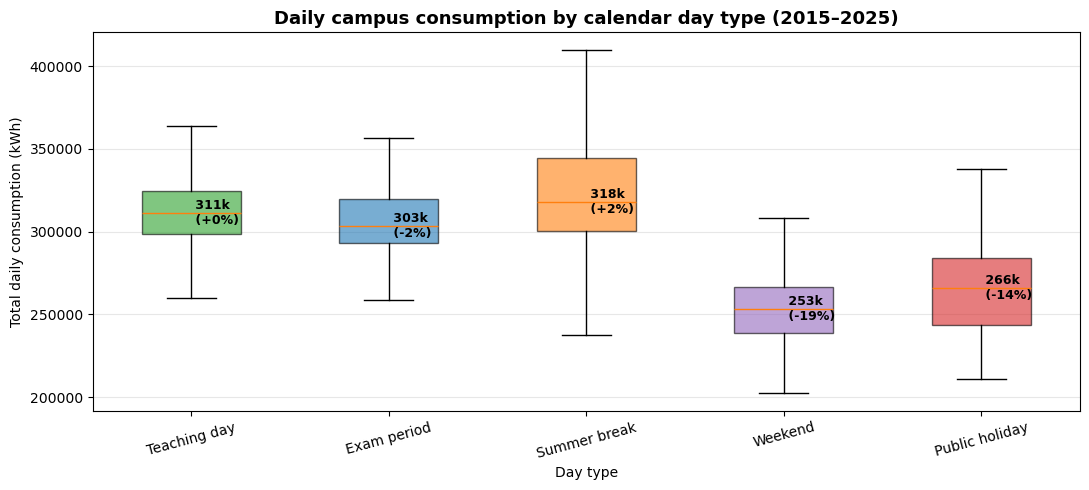

In [6]:
# Plot 1: Daily consumption by day type (the key comparison)

# Order day types for plotting
order = ['Teaching day', 'Exam period', 'Summer break', 'Weekend', 'Public holiday']
plot_data = daily_df[daily_df['day_type'].isin(order)]

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#9467bd', '#d62728']

bp = ax.boxplot(
    [plot_data.loc[plot_data['day_type']==t, 'daily_total_kwh'].values for t in order],
    labels=order, patch_artist=True, showfliers=False
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add median values as text
medians = [plot_data.loc[plot_data['day_type']==t, 'daily_total_kwh'].median() for t in order]
teaching_median = medians[0]
for i, m in enumerate(medians):
    pct_diff = (m - teaching_median) / teaching_median * 100
    ax.text(i+1, m, f' {m/1e3:.0f}k\n ({pct_diff:+.0f}%)', 
            ha='left', va='center', fontsize=9, fontweight='bold')

ax.set_title('Daily campus consumption by calendar day type (2015–2025)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Total daily consumption (kWh)')
ax.set_xlabel('Day type')
ax.grid(alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

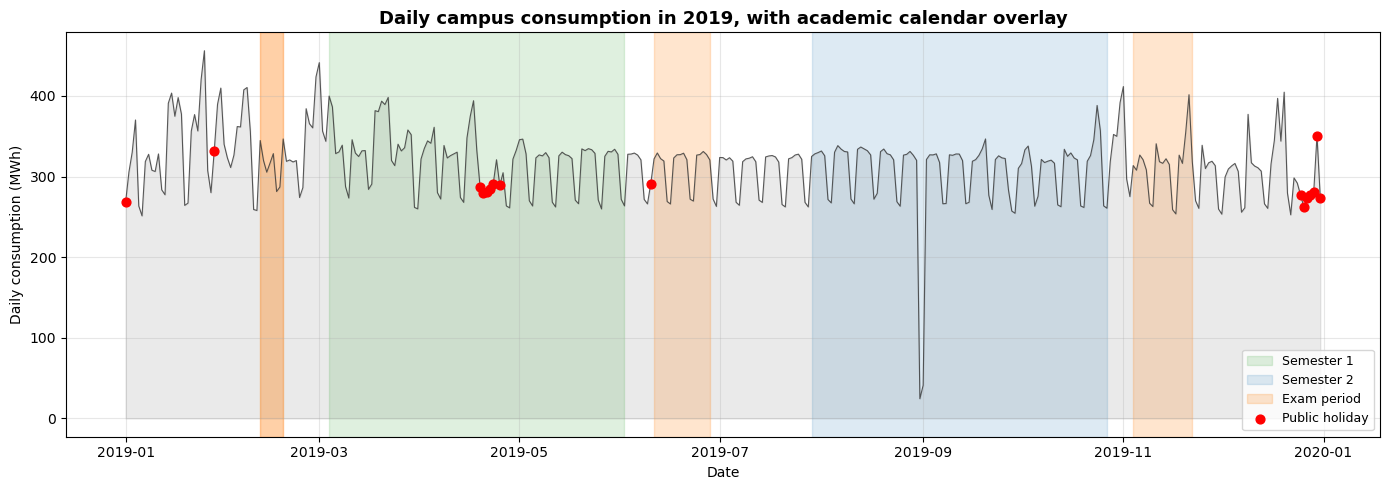

In [9]:
# Plot 2: One year of daily consumption with semester shading
# Choose 2019, Pre-COVID, normal year
target_year = 2019 

year_data = daily_df[daily_df.index.year == target_year].copy()

fig, ax = plt.subplots(figsize=(14, 5))

# Plot consumption line
ax.plot(year_data.index, year_data['daily_total_kwh']/1e3,
        color='#333333', linewidth=0.8, alpha=0.8)
ax.fill_between(year_data.index, year_data['daily_total_kwh']/1e3,
                 alpha=0.1, color='#333333')

# Shade semester periods
sem1 = year_data[year_data['is_semester_1']==1]
if len(sem1) > 0:
    ax.axvspan(sem1.index.min(), sem1.index.max(), 
               alpha=0.15, color='#2ca02c', label='Semester 1')

sem2 = year_data[year_data['is_semester_2']==1]
if len(sem2) > 0:
    ax.axvspan(sem2.index.min(), sem2.index.max(), 
               alpha=0.15, color='#1f77b4', label='Semester 2')

exam = year_data[year_data['is_exam_period']==1]
if len(exam) > 0:
    # exam periods can be disjoint, find each contiguous block
    exam_dates = exam.index
    breaks = (exam_dates[1:] - exam_dates[:-1]).days > 1
    starts = [exam_dates[0]] + list(exam_dates[1:][breaks])
    ends = list(exam_dates[:-1][breaks]) + [exam_dates[-1]]
    for s, e in zip(starts, ends):
        ax.axvspan(s, e, alpha=0.2, color='#ff7f0e')
    ax.axvspan(starts[0], ends[0], alpha=0.2, color='#ff7f0e', label='Exam period')

# Mark public holidays as red dots
ph = year_data[year_data['is_public_holiday']==1]
if len(ph) > 0:
    ax.scatter(ph.index, ph['daily_total_kwh']/1e3,
               color='red', s=40, zorder=5, label='Public holiday')

ax.set_title(f'Daily campus consumption in {target_year}, with academic calendar overlay',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily consumption (MWh)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

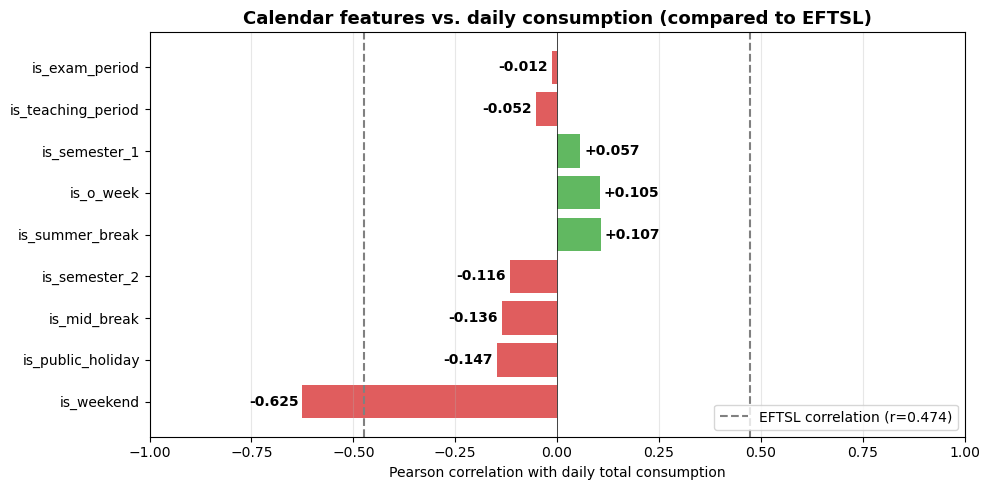


Correlation summary (sorted by |r|):
           feature  pearson_r
        is_weekend  -0.625082
 is_public_holiday  -0.147449
      is_mid_break  -0.136280
     is_semester_2  -0.116485
   is_summer_break   0.107020
         is_o_week   0.104891
     is_semester_1   0.056618
is_teaching_period  -0.051689
    is_exam_period  -0.012196


In [10]:
# Plot 3: Correlation of each calendar feature with daily consumption

calendar_features = ['is_semester_1', 'is_semester_2', 'is_teaching_period',
                     'is_exam_period', 'is_o_week', 'is_summer_break',
                     'is_mid_break', 'is_public_holiday', 'is_weekend']

correlations = {}
for feat in calendar_features:
    r = daily_df[[feat, 'daily_total_kwh']].corr().iloc[0,1]
    correlations[feat] = r

corr_df = pd.DataFrame(list(correlations.items()), columns=['feature','pearson_r'])
corr_df = corr_df.sort_values('pearson_r', key=abs, ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#2ca02c' if r > 0 else '#d62728' for r in corr_df['pearson_r']]
bars = ax.barh(corr_df['feature'], corr_df['pearson_r'], color=colors_bar, alpha=0.75)

# Reference line for EFTSL correlation
ax.axvline(0.474, color='gray', linestyle='--', linewidth=1.5, 
           label='EFTSL correlation (r=0.474)')
ax.axvline(-0.474, color='gray', linestyle='--', linewidth=1.5)

# Add value labels
for bar, r in zip(bars, corr_df['pearson_r']):
    ax.text(r + (0.01 if r > 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{r:+.3f}', va='center', ha='left' if r > 0 else 'right',
            fontsize=10, fontweight='bold')

ax.set_xlabel('Pearson correlation with daily total consumption')
ax.set_title('Calendar features vs. daily consumption (compared to EFTSL)',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlim(-1, 1)
ax.legend(loc='lower right')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nCorrelation summary (sorted by |r|):")
print(corr_df.to_string(index=False))

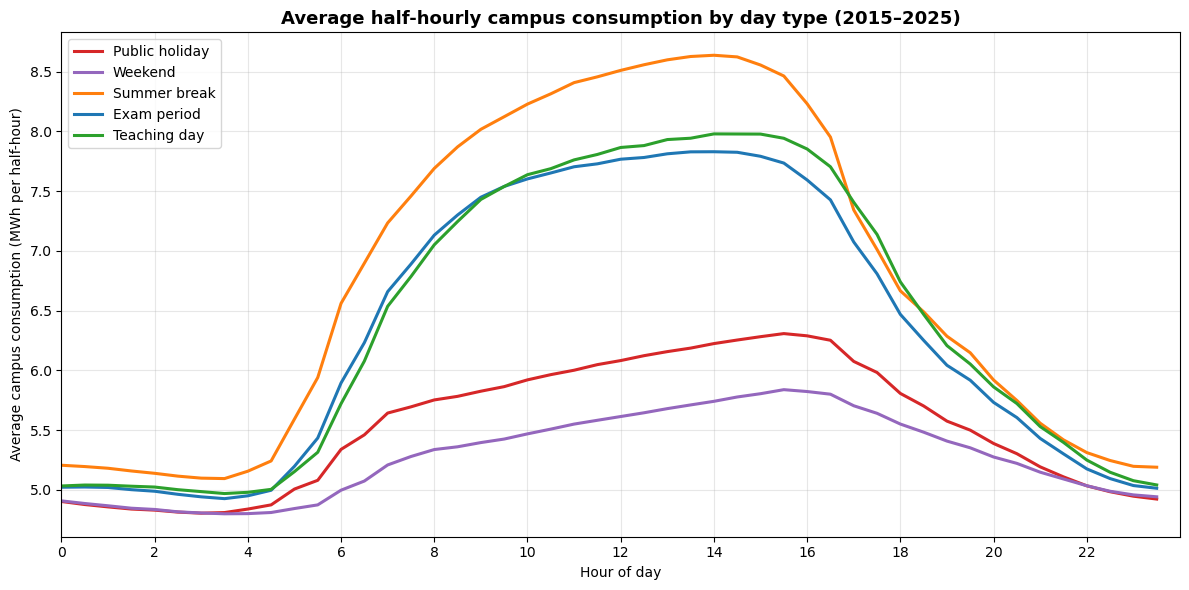

In [ ]:
# Plot 4: Intra-day half-hourly consumption pattern by day type

# Add half-hour-of-day column to df for grouping
df['half_hour'] = df['date'].dt.hour + df['date'].dt.minute / 60

# Identify NMI columns and sum across them to get campus total per row
nmi_cols = [c for c in df.columns 
            if c not in ['date','half_hour','day_of_week','month'] 
            and not c.startswith('is_')]
df['campus_total'] = df[nmi_cols].sum(axis=1)

# Define day types (mutually exclusive priority order)
def classify_day(row):
    if row['is_public_holiday'] == 1:
        return 'Public holiday'
    if row['is_weekend'] == 1:
        return 'Weekend'
    if row['is_teaching_period'] == 1:
        return 'Teaching day'
    if row['is_exam_period'] == 1:
        return 'Exam period'
    if row['is_summer_break'] == 1:
        return 'Summer break'
    return 'Other'

df['day_type'] = df.apply(classify_day, axis=1)

# Compute average half-hourly profile per day type
profile = (
    df.groupby(['day_type', 'half_hour'])['campus_total']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'Teaching day':   '#2ca02c',
    'Exam period':    '#1f77b4',
    'Summer break':   '#ff7f0e',
    'Weekend':        '#9467bd',
    'Public holiday': '#d62728',
}

# Plot order ensures the "interesting" lines (teaching day) are on top
plot_order = ['Public holiday', 'Weekend', 'Summer break', 'Exam period', 'Teaching day']

for day_type in plot_order:
    sub = profile[profile['day_type'] == day_type]
    if len(sub) == 0:
        continue
    ax.plot(sub['half_hour'], sub['campus_total'] / 1e3,
            label=day_type, color=colors[day_type], linewidth=2.2)

ax.set_title('Average half-hourly campus consumption by day type (2015–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average campus consumption (MWh per half-hour)')
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 24)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Clean up the helper columns
df = df.drop(columns=['half_hour', 'campus_total', 'day_type'])